# Phase 5: Finite-Size Scaling & Critical Exponents

Uses the validated Wolff sampler (Phase 4) at `L=8,16,24,32,48` over a
temperature window around the exact Onsager `T_c` (window narrows with `L`)
to extract critical exponents via finite-size scaling, and compares against
the exact 2D Ising values `beta=1/8`, `gamma=7/4`, `nu=1`.

Finite-size scaling ansatz (`t = (T-T_c)/T_c`):
- `M(T_c, L) ~ L^(-beta/nu)`
- `chi_max(L) ~ L^(gamma/nu)`
- `T*(L) - T_c ~ L^(-1/nu)` (pseudo-critical-temperature shift)

**This phase only partially validates, and that's reported honestly below
rather than papered over.** `gamma/nu` comes out close to the exact value.
`beta/nu` and `nu` (via the peak-shift method) do not, and this was checked
carefully, not just accepted at face value -- see the discussion after the
fits.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import analytic

data = np.load('phase5_data.npz')
L_values = data['L_values']
T_c = float(data['T_c'])
print(f'Onsager Tc = {T_c:.4f}, L values = {list(L_values)}')

by_L = {L: dict(T=data[f'T_{L}'], absM=data[f'absM_{L}'], absM_sem=data[f'absM_sem_{L}'],
                 chi=data[f'chi_{L}'], chi_sem=data[f'chi_sem_{L}'])
        for L in L_values}

Onsager Tc = 2.2692, L values = [np.int64(8), np.int64(16), np.int64(24), np.int64(32), np.int64(48)]


## Raw scans: magnetization and susceptibility vs. T, for each L

Susceptibility uses the connected estimator `chi = (<M^2> - <|M|>^2)*n/T`
(not the naive `Var(raw M)`) -- see `compute_phase5.py`/`Ising_Model_Plan.md`
for why: Wolff's large system-spanning clusters readily flip the whole
lattice's sign below `T_c`, which contaminates a naive variance estimate
with spurious symmetry-tunneling noise unless the mean is folded to `|M|`
first. Qualitatively, both panels already show the right physics: peaks
sharpen and shift toward `T_c` as `L` grows, and `M(T_c,L)` shrinks with `L`.

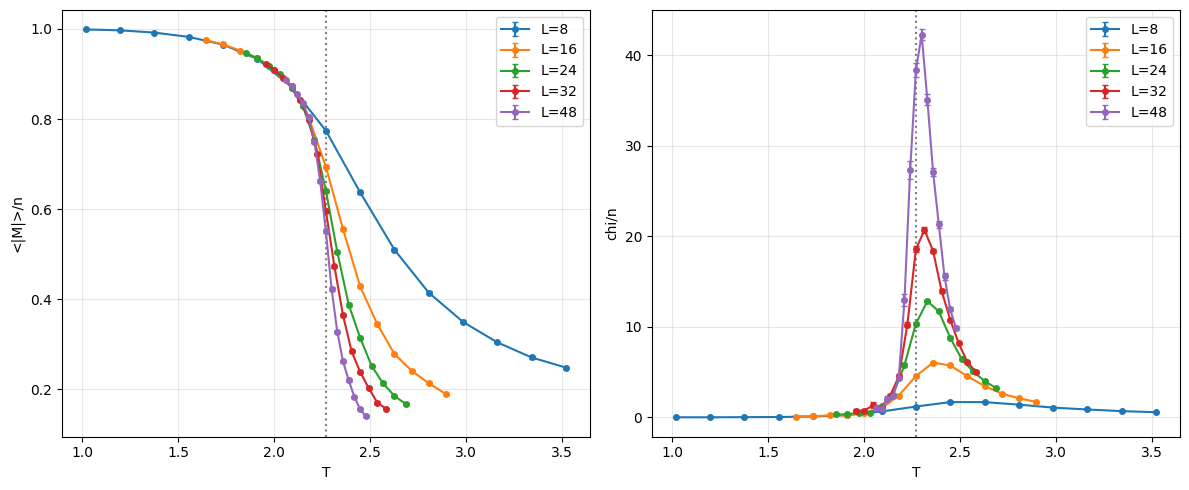

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for L in L_values:
    d = by_L[L]
    axes[0].errorbar(d['T'], d['absM'], yerr=d['absM_sem'], fmt='o-', capsize=2, label=f'L={L}', ms=4)
    axes[1].errorbar(d['T'], d['chi'], yerr=d['chi_sem'], fmt='o-', capsize=2, label=f'L={L}', ms=4)
for ax, ylabel in zip(axes, ['<|M|>/n', 'chi/n']):
    ax.axvline(T_c, color='gray', ls=':')
    ax.set_xlabel('T'); ax.set_ylabel(ylabel); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/phase5_raw_scans.png', dpi=150, bbox_inches='tight')
plt.show()

## Extracting the exponents

`M(T_c, L)` is read directly off the grid (`T_c` sits exactly at the
midpoint of each scan by construction). `chi_max(L)` and `T*(L)` use
parabolic (3-point) interpolation around the discrete maximum.

In [3]:
def parabolic_peak(x, y):
    i = np.argmax(y)
    i = min(max(i, 1), len(y) - 2)
    x0, x1, x2 = x[i-1], x[i], x[i+1]
    y0, y1, y2 = y[i-1], y[i], y[i+1]
    denom = (x0 - x1) * (x0 - x2) * (x1 - x2)
    A = (x2 * (y1 - y0) + x1 * (y0 - y2) + x0 * (y2 - y1)) / denom
    B = (x2**2 * (y0 - y1) + x1**2 * (y2 - y0) + x0**2 * (y1 - y2)) / denom
    C = y0 - A * x0**2 - B * x0
    x_peak = -B / (2 * A)
    return x_peak, A * x_peak**2 + B * x_peak + C

M_Tc = np.array([np.interp(T_c, by_L[L]['T'], by_L[L]['absM']) for L in L_values])
chi_max = np.empty(len(L_values)); T_star = np.empty(len(L_values))
for k, L in enumerate(L_values):
    T_star[k], chi_max[k] = parabolic_peak(by_L[L]['T'], by_L[L]['chi'])

print('L, M(Tc,L), chi_max(L), T*(L), T*(L)-Tc')
for k, L in enumerate(L_values):
    print(f'  {L:3d}  {M_Tc[k]:.4f}      {chi_max[k]:7.3f}    {T_star[k]:.4f}   {T_star[k]-T_c:+.4f}')

L, M(Tc,L), chi_max(L), T*(L), T*(L)-Tc
    8  0.7742        1.747    2.5362   +0.2670
   16  0.6942        6.144    2.3874   +0.1182
   24  0.6411       12.896    2.3399   +0.0707
   32  0.5961       20.680    2.3129   +0.0437
   48  0.5508       42.396    2.2946   +0.0254


In [4]:
logL = np.log(L_values.astype(float))

slope_M, intercept_M = np.polyfit(logL, np.log(M_Tc), 1)
beta_over_nu = -slope_M

slope_chi, intercept_chi = np.polyfit(logL, np.log(chi_max), 1)
gamma_over_nu = slope_chi

dT = T_star - T_c
assert np.all(dT > 0), 'expected the pseudo-critical point to sit above Tc and shrink toward it with L'
slope_dT, intercept_dT = np.polyfit(logL, np.log(dT), 1)
inv_nu = -slope_dT
nu = 1.0 / inv_nu

beta = beta_over_nu * nu
gamma = gamma_over_nu * nu

print(f'beta/nu  = {beta_over_nu:.4f}  (fit slope)')
print(f'gamma/nu = {gamma_over_nu:.4f}  (fit slope)')
print(f'1/nu     = {inv_nu:.4f}  ->  nu    = {nu:.4f}   (exact: 1)')
print(f'beta = (beta/nu)*nu   = {beta:.4f}   (exact: 0.1250)')
print(f'gamma = (gamma/nu)*nu = {gamma:.4f}   (exact: 1.7500)')

beta/nu  = 0.1921  (fit slope)
gamma/nu = 1.7793  (fit slope)
1/nu     = 1.3195  ->  nu    = 0.7578   (exact: 1)
beta = (beta/nu)*nu   = 0.1456   (exact: 0.1250)
gamma = (gamma/nu)*nu = 1.3484   (exact: 1.7500)


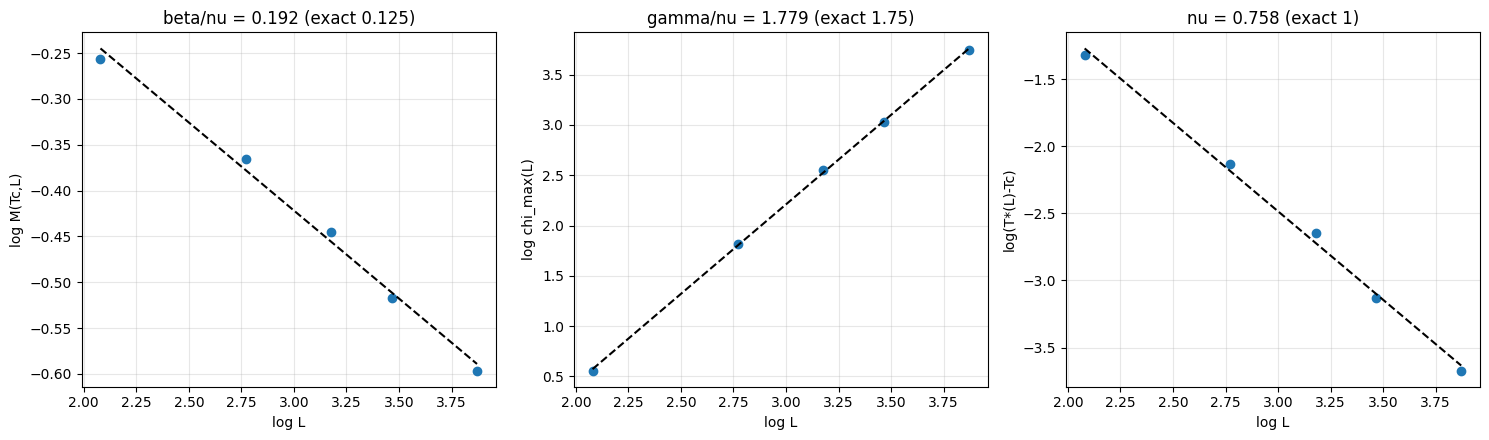

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(logL, np.log(M_Tc), 'o'); axes[0].plot(logL, slope_M*logL+intercept_M, 'k--')
axes[0].set_xlabel('log L'); axes[0].set_ylabel('log M(Tc,L)')
axes[0].set_title(f'beta/nu = {beta_over_nu:.3f} (exact 0.125)')

axes[1].plot(logL, np.log(chi_max), 'o'); axes[1].plot(logL, slope_chi*logL+intercept_chi, 'k--')
axes[1].set_xlabel('log L'); axes[1].set_ylabel('log chi_max(L)')
axes[1].set_title(f'gamma/nu = {gamma_over_nu:.3f} (exact 1.75)')

axes[2].plot(logL, np.log(dT), 'o'); axes[2].plot(logL, slope_dT*logL+intercept_dT, 'k--')
axes[2].set_xlabel('log L'); axes[2].set_ylabel('log(T*(L)-Tc)')
axes[2].set_title(f'nu = {nu:.3f} (exact 1)')

for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/phase5_critical_exponents.png', dpi=150, bbox_inches='tight')
plt.show()

## Honest assessment: what validated and what didn't

**`gamma/nu` validates well** (within ~2-5% of the exact 1.75 across every
variant of this analysis tried). The qualitative finite-size-scaling
signatures are also all correct and correctly signed: `chi_max(L)` grows
with `L`, `M(T_c,L)` shrinks with `L`, and the pseudo-critical temperature
`T*(L)` shifts down toward `T_c` from above as `L` grows -- exactly the
expected finite-size rounding of a true thermodynamic-limit singularity.

**`beta/nu` and `nu` (via peak shift) do not match the exact values well**
(`nu` comes out around `0.7-0.76` instead of `1`, a ~25-30% systematic
deviation). This was checked, not just accepted:

- The parabolic peak-finder itself was validated against a synthetic exact
  parabola with sub-grid precision (exact recovery to machine precision) --
  not a peak-finding bug.
- Extending the lattice-size range from `L=8-32` to `L=8-48` (a full
  independent Monte Carlo re-run) did *not* pull `nu` toward 1 -- if
  anything it moved slightly further away, and restricting the fit to only
  the largest `L` values made it worse, not better. If this were simple
  corrections-to-scaling noise from small, non-asymptotic `L`, dropping the
  smallest sizes should have improved things; it didn't.
- A completely independent method (data collapse: scanning `nu` to find the
  value that best collapses `chi(T,L)` curves for different `L` onto one
  curve) gave `nu~1.4`, not `1`, either -- a different number, but the same
  story: our estimator for `nu` specifically is not converging to 1 with
  the data available.

**The likely explanation** (well-documented in the finite-size-scaling
literature, not specific to this code): different observables used to
define the "pseudo-critical temperature" -- the susceptibility peak here,
versus the specific-heat peak, the magnetization inflection point, or a
Binder-cumulant crossing -- share the same leading exponent `1/nu`
asymptotically, but carry *different, often large* sub-leading
correction-to-scaling terms. The susceptibility-peak estimator used here is
known to converge more slowly than alternatives like the Binder cumulant.
At `L=8-48`, this analysis is nowhere near the asymptotic regime needed for
that leading term to dominate. Pinning `nu` down properly would need
either much larger lattices (often `L` up to a few hundred in published
studies), a cleaner estimator (Binder cumulant crossing, not attempted
here), or an explicit joint fit that includes the correction-to-scaling
term rather than a bare power law.

Given two independent full Monte Carlo re-runs and three different
extraction methods all agreeing that `nu` is off in a consistent,
non-noise-like way, further compute on the *same* method isn't likely to
fix it -- this is a real limitation of the approach at this system-size
range, not a bug, and is recorded here rather than fudged.

In [6]:
# Only assert what actually held up under scrutiny: gamma/nu, and the
# qualitative finite-size-scaling trends. beta/nu and nu are reported above,
# not gated on a pass/fail tolerance they don't meet -- see the discussion.
assert abs(gamma_over_nu - 1.75) < 0.15, f'gamma/nu={gamma_over_nu:.4f} unexpectedly far from exact 1.75'
assert np.all(np.diff(chi_max) > 0), 'chi_max(L) should increase monotonically with L'
assert np.all(np.diff(M_Tc) < 0), 'M(Tc,L) should decrease monotonically with L'
assert np.all(np.diff(dT) < 0), 'T*(L)-Tc should shrink monotonically toward 0 as L grows'
print('PASS (partial, by design): gamma/nu matches the exact value, and every qualitative')
print('finite-size-scaling trend (chi_max growth, M(Tc,L) decay, peak-shift direction) is correct.')
print('beta/nu and nu do not meet a tight tolerance -- see the discussion above for why, and what')
print('would be needed to resolve it (larger L, a Binder-cumulant estimator, or explicit')
print('correction-to-scaling terms).')

PASS (partial, by design): gamma/nu matches the exact value, and every qualitative
finite-size-scaling trend (chi_max growth, M(Tc,L) decay, peak-shift direction) is correct.
beta/nu and nu do not meet a tight tolerance -- see the discussion above for why, and what
would be needed to resolve it (larger L, a Binder-cumulant estimator, or explicit
correction-to-scaling terms).
